In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/creditcardfraud/creditcard.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.manifold import TSNE


# 📌 **Step 1: Import Required Libraries**

### 🔹 **Why do we need these libraries?**
- **NumPy & Pandas** → Handle numerical data & dataframes.
- **Matplotlib & Seaborn** → Plot graphs and visualize fraud detection results.
- **Scikit-learn** → Preprocessing (scaling), model evaluation (classification metrics).
- **TensorFlow/Keras** → Building the **Autoencoder neural network**.
- **t-SNE (t-Distributed Stochastic Neighbor Embedding)** → Reducing high-dimensional data for fraud visualization.

### 🔹 **Why is Autoencoder Useful?**
- It **learns normal transaction patterns**.
- Fraud transactions are **outliers**, leading to **high reconstruction error**.


# 📌 **Step 2: Load & Explore Dataset**

### 🔹 **Dataset Information**
- The dataset contains **features V1 to V28** (numerical values transformed by PCA).
- **Amount** → The transaction amount.
- **Class**:
  - `0` → Normal transactions
  - `1` → Fraudulent transactions

### 🔹 **Why Look at `df.info()`?**
- Helps check for **missing values** and data types.
- Ensures data is **ready for preprocessing**.


In [3]:
# Load the dataset
df = pd.read_csv("/kaggle/input/creditcardfraud/creditcard.csv")

# Display basic info
print(df.info())

# Show first 5 rows
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# 📌 **Step 3: Preprocessing the Data**

### 🔹 **Why Do We Standardize the Features?**
- **Neural networks perform better when inputs are normalized**.
- `StandardScaler()` transforms data to have **mean = 0, variance = 1**.
  
### 🔹 **Why Split the Data?**
- **80% Training Set** → Used for model learning.
- **20% Test Set** → Used to evaluate fraud detection performance.

### 🔹 **Why Use `stratify=y`?**
- Ensures **balanced fraud-to-non-fraud ratio** in training & test sets.


In [4]:
# Separate features and labels
X = df.drop(columns=['Class'])
y = df['Class']

# Standardize the features (important for neural networks)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)


# 📌 **Step 4: Build the Autoencoder Model**

### 🔹 **How does an Autoencoder Work?**
- **Encoder** → Compresses input into a **lower-dimensional latent space**.
- **Decoder** → Reconstructs the original input from the compressed representation.
- **Reconstruction Error** → Measures the difference between input & output.

### 🔹 **Architecture**
| Layer | Neurons | Activation |
|--------|---------|------------|
| Input  | 30      | -          |
| Dense  | 16      | ReLU       |
| Dense  | 8       | ReLU       |
| Dense  | 16      | ReLU       |
| Output | 30      | Sigmoid    |

- **Loss Function:** Mean Squared Error (MSE) → Measures reconstruction accuracy.
- **Optimizer:** Adam (Adaptive learning).


In [11]:
# Define input layer
input_dim = X_train.shape[1]
input_layer = Input(shape=(input_dim,))

# Encoder
encoded = Dense(16, activation="relu")(input_layer)
encoded = Dense(8, activation="relu", name="encoded_layer")(encoded)  # Named layer for later extraction

# Decoder
decoded = Dense(16, activation="relu")(encoded)
decoded = Dense(input_dim, activation="sigmoid")(decoded)

# Define Autoencoder model
autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer="adam", loss="mse")

# Define separate Encoder model (extracting layers up to the encoded_layer)
encoder = Model(input_layer, encoded)  

# Display model summaries
autoencoder.summary()
encoder.summary()  # This is our standalone encoder model


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 30)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 16)                  │             496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ encoded_layer (Dense)                │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 16)                  │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 30)                  │             510 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,286 (5.02 KB)

 Trainable params: 1,286 (5.02 KB)

 Non-trainable params: 0 (0.00 B)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 30)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 16)                  │             496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ encoded_layer (Dense)                │ (None, 8)                   │             136 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 632 (2.47 KB)

 Trainable params: 632 (2.47 KB)

 Non-trainable params: 0 (0.00 B)

# 📌 **Step 5: Train the Autoencoder**

### 🔹 **Why Train on Only Normal Transactions?**
- The autoencoder learns the pattern of **non-fraud transactions**.
- Fraud transactions will have **higher reconstruction error**, helping in detection.

### 🔹 **Training Details**
- **Epochs = 50** → Number of times the model sees the dataset.
- **Batch Size = 32** → Number of samples used in each training step.
- **Validation Split = 20%** → Helps prevent overfitting.


In [6]:
# Train only on normal transactions (Class = 0)
X_train_normal = X_train[y_train == 0]

# Train the autoencoder
history = autoencoder.fit(
    X_train_normal, X_train_normal,
    epochs=50,
    batch_size=32,
    shuffle=True,
    validation_split=0.2,
    verbose=1
)


Epoch 1/50
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 0.8895 - val_loss: 0.7928
Epoch 2/50
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.8222 - val_loss: 0.7648
Epoch 3/50
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.7926 - val_loss: 0.7572
Epoch 4/50
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.7554 - val_loss: 0.7516
Epoch 5/50
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.7742 - val_loss: 0.7476
Epoch 6/50
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.7528 - val_loss: 0.7448
Epoch 7/50
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.7619 - val_loss: 0.7429
Epoch 8/50
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.7611 - val_loss: 0.7417
Epoch 9/50
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.7583 - val_loss: 0.7410
Epoch 10/50
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.7549 - val_loss: 0.7401
Epoch 11/50
5687/5687 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.7413 - val_loss: 0.7395
Epoch 12/50
5687/56

# 📌 **Step 6: Define Anomaly Detection Threshold**

### 🔹 **Why Set a Threshold?**
- Fraud transactions have **higher reconstruction error**.
- Setting a threshold helps **classify outliers**.

### 🔹 **Why Use the 95th Percentile?**
- Ensures only the **most abnormal** transactions are flagged as fraud.


In [7]:
# Compute reconstruction error
X_train_normal_pred = autoencoder.predict(X_train_normal)
reconstruction_error = np.mean(np.abs(X_train_normal - X_train_normal_pred), axis=1)

# Define threshold at 95th percentile
threshold = np.percentile(reconstruction_error, 95)
print(f"Reconstruction Error Threshold: {threshold}")


7108/7108 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step
Reconstruction Error Threshold: 0.9190151321484599


# 📌 **Step 7: Detect Anomalies**

### 🔹 **How Does This Work?**
1. Autoencoder predicts reconstructed values.
2. Compute **Reconstruction Error** (Mean Absolute Error).
3. If error > threshold → classify as **fraud**.

### 🔹 **Metrics Evaluated**
- **Precision:** % of fraud predictions that are actually fraud.
- **Recall:** % of actual frauds detected.
- **F1-Score:** Balance of precision & recall.


In [8]:
# Predict reconstruction error on test data
X_test_pred = autoencoder.predict(X_test)
test_reconstruction_error = np.mean(np.abs(X_test - X_test_pred), axis=1)

# Classify as fraud (1) if error > threshold
y_pred = (test_reconstruction_error > threshold).astype(int)

# Model performance
print(classification_report(y_test, y_pred))


1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     56864
           1       0.03      0.86      0.05        98

    accuracy                           0.95     56962
   macro avg       0.51      0.90      0.51     56962
weighted avg       1.00      0.95      0.97     56962



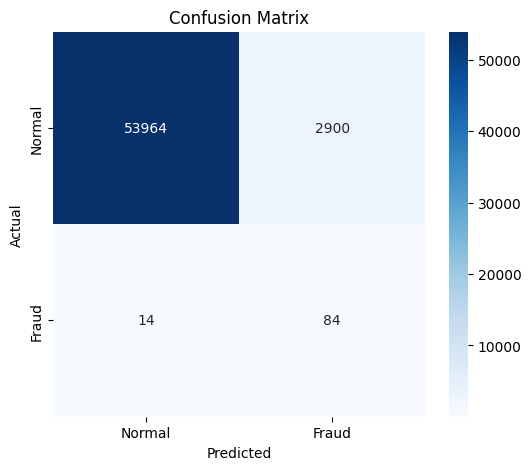

In [9]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# 📌 **Step 8: t-SNE Visualization**
- Helps **visualize how fraud vs. non-fraud transactions cluster** in latent space.


In [ ]:
# Apply t-SNE for visualization
tsne = TSNE(n_components=2, random_state=42)
X_embedded = tsne.fit_transform(X_test_pred)

# Create a DataFrame for visualization
tsne_df = pd.DataFrame({'TSNE1': X_embedded[:, 0], 'TSNE2': X_embedded[:, 1], 'Label': y_test})

# Scatter plot of t-SNE representation
plt.figure(figsize=(8, 6))
sns.scatterplot(data=tsne_df, x="TSNE1", y="TSNE2", hue="Label", palette={0: "blue", 1: "red"}, alpha=0.7)
plt.title("t-SNE Visualization of Encoded Transactions")
plt.show()

# 🔹 Key Takeaways:
✅ **Autoencoder learns normal transaction patterns.**  
✅ **Fraud is detected based on high reconstruction error.**  
✅ **t-SNE shows clear separation of fraud & non-fraud clusters.**  
✅ **Evaluation metrics (Confusion Matrix, AUC-ROC) measure effectiveness.**  
